In [6]:
%matplotlib inline
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.circuit.library import unitary_overlap
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService

In [7]:
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv",
    "dataset_graph7.csv",
)

('dataset_graph7.csv', <http.client.HTTPMessage at 0x1d7a6a4ea50>)

In [8]:
def visualize_counts(res_counts, num_qubits, num_shots):
    zero_prob = res_counts.get(0,0)
    top_10 = dict(
        sorted(res_counts.items(), key=lambda item: item[1], reverse=True)[:10]
    )

    top_10.update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    x_vals, y_vals = list(zip(*by_key.items()))
    x_vals = [bin(x_val)[2:].zfill(num_qubits) for x_val in x_vals]
    y_vals_prob = []
    for t in range(len(y_vals)):
        y_vals_prob.append(y_vals[t] / num_shots)
    y_vals = y_vals_prob
    plt.bar(x_vals,y_vals)
    plt.xticks(rotation=75)
    plt.title("Sampling Results")
    plt.xlabel("Measured bitstring")
    plt.ylabel("Probability")
    plt.show()

In [9]:
def get_training_data():
    df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)
    training_data = df.values[:20, :]
    ind = np.argsort(training_data[:, -1])
    X_train = training_data[ind][:, :-1]

    return X_train

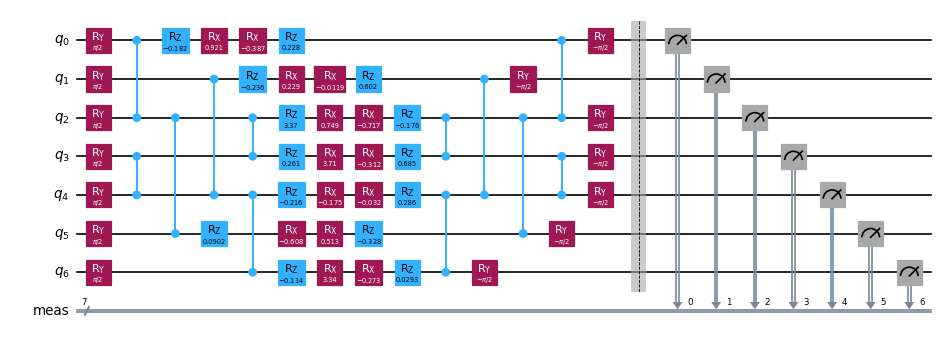

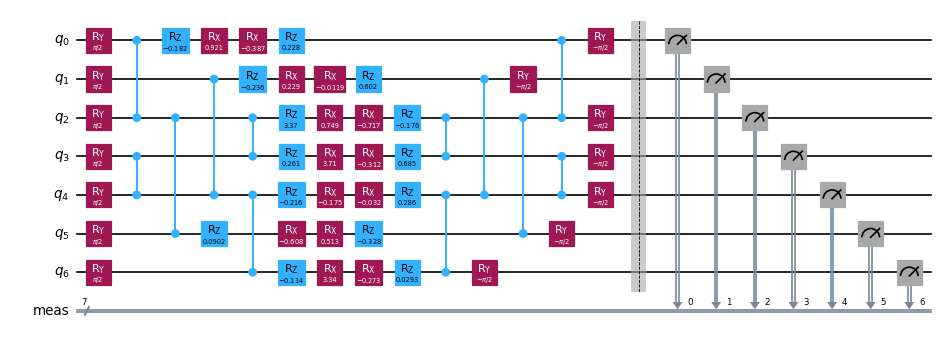

In [12]:
X_train = get_training_data()

# Empty kernel matrix
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)

#Prepare feature map for compute
num_features = np.shape(X_train)[1]
num_qubits = int(num_features/2)
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]
fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits *2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

# Assign tunable param to known optimal value
x1 = 14
x2 = 19
unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

# Create the overlap circuit
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()
overlap_circ.draw("mpl", scale=0.6, style="iqp")


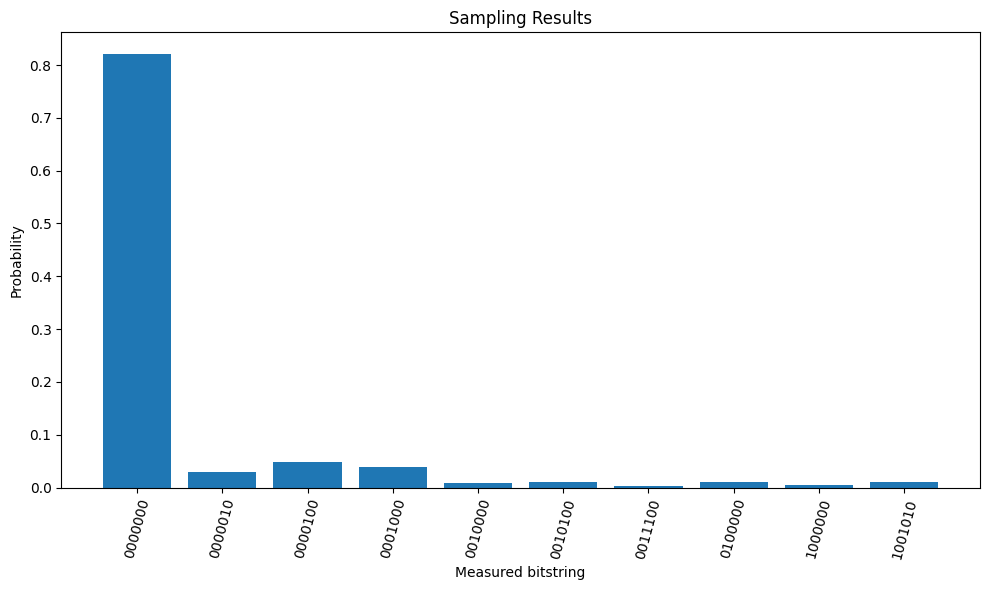

In [13]:
# Input : Abstract circuit, Output: Quasi-probability distrib

sampler = StatevectorSampler()

num_shots = 10_000
results = sampler.run([overlap_circ], shots = num_shots).result()
counts = results[0].data.meas.get_int_counts()

visualize_counts(counts, num_qubits, num_shots)

In [14]:
kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
print(f"Fidelity (simulator): {kernel_matrix[x1, x2]}")

Fidelity (simulator): 0.8209


Hardware Example

In [17]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# ------------------------------ Step 1 ------------------------------
# Prepare training data
X_train = get_training_data()

# Empty kernel matrix
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)

# Prepare feature map for computing overlap
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)
entangler_map = [[0, 2], [3, 4], [2, 5], [1, 4], [2, 3], [4, 6]]
fm = QuantumCircuit(num_qubits)
training_param = Parameter("θ")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)
for cz in entangler_map:
    fm.cz(cz[0], cz[1])
for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i + 1], i)
    fm.rx(-2 * feature_params[2 * i], i)

# Assign tunable parameter to known optimal value and set the data params for first two samples
x1 = 14
x2 = 19
unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

# Create the overlap circuit
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all()

# ------------------------------ Step 2 ------------------------------
service = QiskitRuntimeService()
# backend = service.least_busy(
#    operational=True, simulator=False, min_num_qubits=overlap_circ.num_qubits
# )
backend = service.backend("ibm_kingston")
print(f"Using backend: {backend.name}")
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

# ------------------------------ Step 3 ------------------------------
sampler = Sampler(mode=backend)
sampler.options.environment.job_tags = ["TUT_QKT"]

num_shots = 10_000
results = sampler.run([overlap_ibm], shots=num_shots).result()
counts = results[0].data.meas.get_int_counts()
visualize_counts(counts, num_qubits, num_shots)

# ------------------------------ Step 4 ------------------------------
kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
print(f"Fidelity (hardware): {kernel_matrix[x1, x2]}")

Using backend: ibm_kingston


c:\python312\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:1003: UserWarning: The backend ibm_kingston currently has a status of maintenance.
  warnings.warn(


RuntimeInvalidStateError: 'Unable to retrieve result for job d8m3gc832u0s73fambrg. Job was cancelled.'